In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from joblib import dump, load
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib
import scienceplots

In [19]:
#Definições para os gráficos
plt.style.use(['science', 'grid'])

'''
POD - Dados de treino banco de dados A
POD2 - Dados de validação banco de dados B
POD3 - Dados de treino com o modelo de referência (todos sensores sem reconstrução)
POD4 - Dados de validação com o modelo de referência (todos sensores sem reconstrução)
POD 5 - Dados de treino com o modelo de referência 2 (sensores selecionados sem reconstrução)
POD 6 - Dados de validação com o modelo de referência 2 (sensores selecionados sem reconstrução)
'''

SAVE_PATH = './POD2'

LATEX_WIDTH = 6.29707

aspect_ratio = 6/8
scale = 1.0
FIG_WIDTH = LATEX_WIDTH * scale
FIG_HEIGHT = FIG_WIDTH * aspect_ratio

plt.rcParams['figure.figsize'] = [FIG_WIDTH, FIG_HEIGHT]
plt.rcParams["font.family"] = "serif"

metadata={
            'Creator' : 'Guilherme Zerwes',
            'Producer': 'Guilherme Zerwes',
            'CreationDate': None
        }

plt.rcParams['text.usetex'] = False

%matplotlib inline
# matplotlib.use("pdf")
# plt.switch_backend('nbAgg')
plt.get_backend()

'module://matplotlib_inline.backend_inline'

In [3]:
#Load all coeficients
path = '../00 - Cópia/Coefs teste'
files = sorted([file for file in os.listdir(path) if file.endswith('.txt')], key=lambda x: int(x[5:-4]))

In [6]:
#Input parameters
n_window = 128

nr = 15
n_sensors = 30
n_cases = len(files)

x_data = np.zeros((len(files)*n_window, nr*n_sensors))
y_data = np.zeros((len(files)*n_window))

In [7]:
#Loads to x_data variable
print('Loading files...')
for i in range(len(files)):
    file_path = os.path.join(path,files[i])
    aux_in = i*n_window
    aux_end = (i+1)*n_window
    x_data[aux_in:aux_end] = np.loadtxt(file_path)
    y_data[aux_in:aux_end] = i 

#Train test split
# x_train, x_test, y_train, y_test = train_test_split(x_data,y_data, train_size=0.8, random_state=42)

x_test, y_test = x_data, y_data

Loading files...


In [ ]:
#Model training
'''
classifierRec.joblib - 13 sensores + reconstrução
classfRef.joblib - 13 sensores
classifier.joblib - 30 sensores
'''
# print('Begining training...')
if 'classifierRec.joblib' not in os.listdir('../outputs/modelos'):
    print('Training model...')
    model = RandomForestClassifier()
    model.fit(x_train,y_train)
    dump(model, '../outputs/modelos/classifierRec.joblib')
else:
    print('Loading model...')
    model = load('../outputs/modelos/classifierRec.joblib')

Loading model...


In [9]:
# print(f'Model score during training: {model.score(x_train,y_train)}')
print(f'Model score during testing: {model.score(x_test,y_test)}')
preds = model.predict_proba(x_test)
yhat = model.predict(x_test)

Model score during testing: 0.9982358870967742


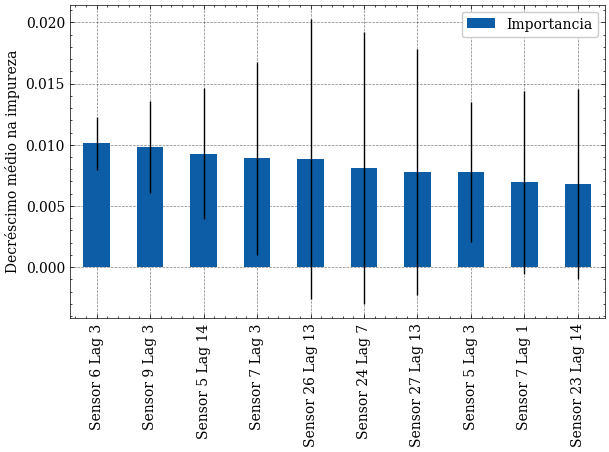

In [8]:
#Feature importance
feature_names = [f'Sensor {j} Lag {i}' for i in range(1,nr+1) for j in range(1,n_sensors+1)]
importances = model.feature_importances_
importance_std = np.std([tree.feature_importances_ for tree in model.estimators_], axis=0)

forest_importances = pd.DataFrame(zip(feature_names, importances), columns=['Nome', 'Importancia'])

forest_importances = forest_importances.sort_values(by='Importancia', ascending=False)

fig, ax = plt.subplots()
forest_importances[:10].plot.bar(yerr=importance_std[:10], ax=ax)
plt.xticks(ticks=range(10), labels=forest_importances[:10]['Nome'])
# ax.set_title("Feature importances using MDI")
ax.set_ylabel("Decréscimo médio na impureza")
fig.tight_layout()


In [10]:
maxProbPreds = np.max(preds,axis=1)
# np.sort(maxProbPreds)
bad_results = np.argwhere(maxProbPreds <= 0.25)[::2,0]
best_results = np.argwhere(maxProbPreds == 1)[::7,0]

In [11]:
np.argwhere((maxProbPreds >= 0.9) & (y_test == 0))[::2,0]

array([ 12,  17,  38,  56,  71,  77,  90, 109, 116], dtype=int64)

In [12]:
def plot_colormap(predictions:np.ndarray, axes:plt.Axes, ytrue:str=None, titulo:str=None, colorbar:bool=None):
    '''Função auxiliar para gerar mapas de calor customizados
    
    inputs:
        predictions: ndarray da forma (30,)

        axes: matplotlib axes para uma figura

        titulo: string com o nome a ser adicionado

        colorbar: boleano indicando se o plot deve ou não conter a colorbar
    outputs:
        mapa de calor customizado
    '''

    #Organiza as predições para o formato desejado
    heat = np.reshape(predictions[1:], (5,6), order='F')
    heatmap = axes.imshow(heat, interpolation='bilinear', cmap='jet', vmin=0, vmax=1)

    #monta os ticks nas juntas
    r = 5
    c = 6

    sensx = [int(i) for i in range(c)]*r
    sensy = [i for i in range(r) for j in range(c)]
    axes.scatter(sensx, sensy, color='black', marker='+')

    # Calcula a coordenada da junta com base no índice da previsão
    if ytrue != 0:
        row = int(np.ceil(ytrue/5))  # Posição i (linha)
        col = int(5) if ytrue%5 == 0 else int(ytrue % 5)  # Posição j (coluna)
    
        #Põe título quando fornecido
        axes.set_title(f'{titulo} ({col},{row})') if titulo else 'nothing'
    else:
        axes.set_title(f'{titulo}') if titulo else 'nothing'

    # Ajustando os ticks e limites para centralizar as células e iniciar em 1
    axes.set_xticks(np.arange(c))
    axes.set_yticks(np.arange(r))
    axes.set_xticklabels(range(1, c + 1))
    axes.set_yticklabels(range(1, r + 1))
    axes.set_xlim(-0.5, c - 0.5)  # Limites ajustados para centralizar
    axes.set_ylim(r - 0.5, -0.5)  # Inverter Y para alinhar visualmente
    axes.set_aspect('auto')

    #Anota as probabilidades em cada junta
    for x in range(c):
        for y in range(r):
            axes.text(x, y-0.2, f'{heat[y, x]:.2f}', color='white', ha='center', va='center', fontsize=8)

    #Adiciona a colorbar se desejado
    if colorbar:
        cbar_ax = fig.add_axes([1.01, 0.15, 0.05, 0.7])  # Posição da colorbar
        cbar = fig.colorbar(heatmap, cax=cbar_ax)
        cbar.set_label('Probabilidade de dano')  # Rótulo da colorbar
        # cbar.ax.tick_params(labelsize=10)  # Tamanho dos ticks
        cbar.ax.yaxis.set_tick_params(pad=5)  # Espaçamento dos números na colorbar
        cbar.outline.set_linewidth(0.5)  # Fino contorno da colorbar

    return heatmap

    

In [90]:
np.argwhere((maxProbPreds >= 0) & (y_test == 0))[:,0]

np.average(preds[0:128], axis=0)*100

array([6.8968750e+01, 7.1093750e-01, 7.7890625e+00, 1.2421875e+00,
       6.7968750e-01, 2.5781250e-01, 1.0156250e+00, 3.4375000e-01,
       1.5781250e+00, 1.4062500e-01, 4.5312500e-01, 1.1640625e+00,
       4.6875000e-02, 5.7031250e-01, 1.0937500e-01, 2.1093750e+00,
       7.9687500e-01, 4.2187500e-01, 7.8125000e-03, 1.5390625e+00,
       2.3437500e-02, 3.0468750e-01, 4.6875000e-02, 1.5625000e-02,
       0.0000000e+00, 5.5468750e-01, 1.9531250e-01, 1.9531250e-01,
       4.6875000e-02, 4.6953125e+00, 3.9765625e+00])

[0.17 0.07 0.16 0.11 0.   0.   0.09 0.   0.05 0.01 0.   0.1  0.   0.01
 0.03 0.03 0.02 0.   0.   0.01 0.   0.   0.01 0.   0.   0.01 0.01 0.
 0.   0.1  0.01]


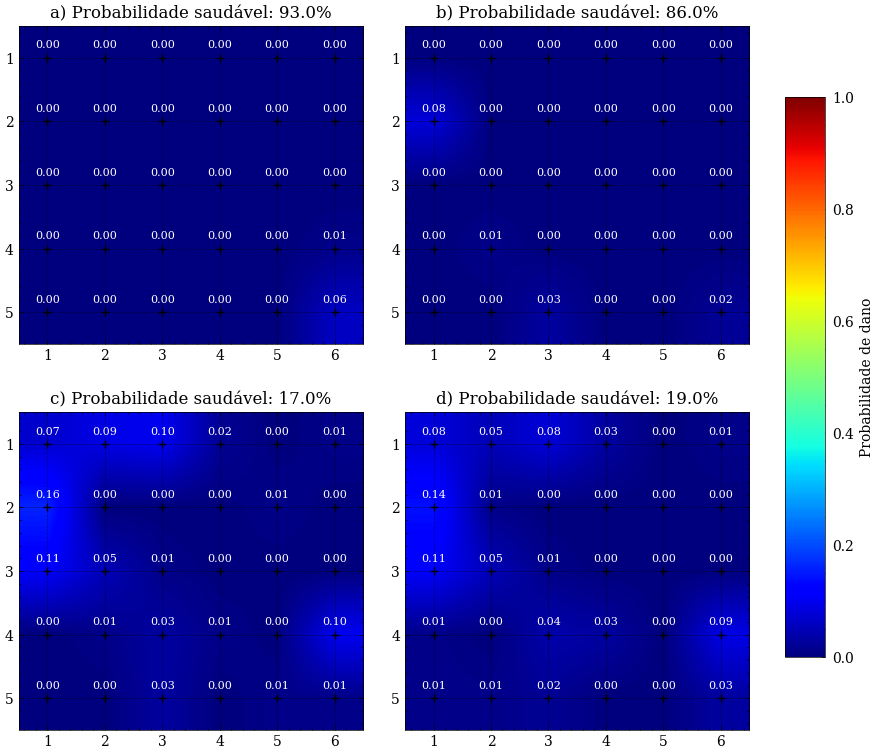

In [21]:
#Plot dos 4 piores resultados

fig = plt.figure(figsize=(8,8)) # Notice the equal aspect ratio
ax = [fig.add_subplot(2,2,i+1) for i in range(4)]

titulo = ['a)', 'b)', 'c)', 'd)']
zeros = [38, 80,  1, 79]
print(preds[1])
for i in range(len(ax)):
    # j = bad_results[i+4]
    # j = best_results[i+15]
    j = zeros[i]

    title = f'{titulo[i]} Dano na junta {int(y_test[j])}' if y_test[j] != 0 else f'{titulo[i]} Probabilidade saudável: {preds[j,0]*100}%'
    heatmap = plot_colormap(predictions=preds[j], axes=ax[i], titulo=title, ytrue=y_test[j])

    plt.tight_layout(pad=2.0)
plt.tight_layout(pad=2.0)

# Barra de cor estilizada
cbar_ax = fig.add_axes([1.01, 0.15, 0.05, 0.7])  # Posição da colorbar
cbar = fig.colorbar(heatmap, cax=cbar_ax)
cbar.set_label('Probabilidade de dano')  # Rótulo da colorbar
cbar.ax.tick_params(labelsize=10)  # Tamanho dos ticks
cbar.ax.yaxis.set_tick_params(pad=5)  # Espaçamento dos números na colorbar
cbar.outline.set_linewidth(0.5)  # Fino contorno da colorbar

plt.show()
# saving_path = SAVE_PATH + '/00 - Piores resultados.pdf'
saving_path = SAVE_PATH + '/00 - Melhores-Piores sem dano.png'
# saving_path = SAVE_PATH + '/00 - Melhores resultados.pdf'
fig.savefig(saving_path, bbox_inches='tight')



C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_9956\1229174110.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.0)


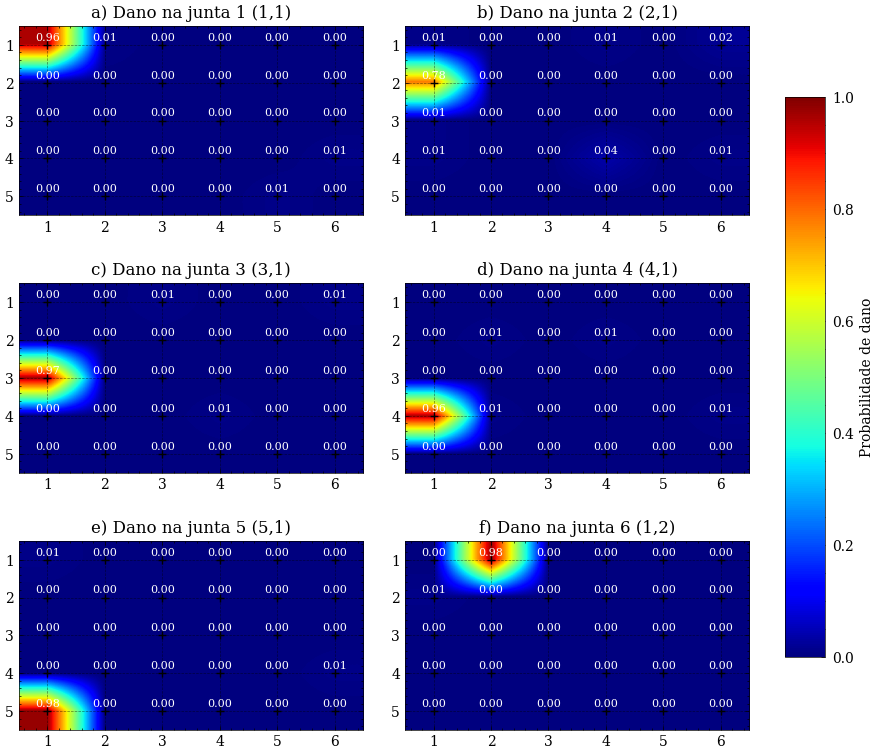

C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_9956\1229174110.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.0)


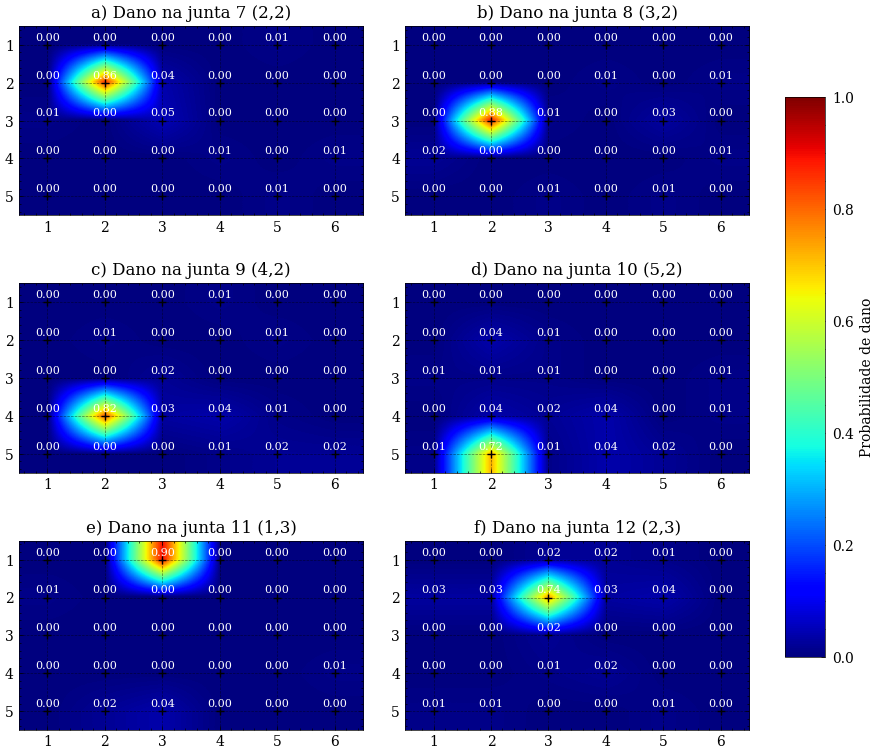

C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_9956\1229174110.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.0)


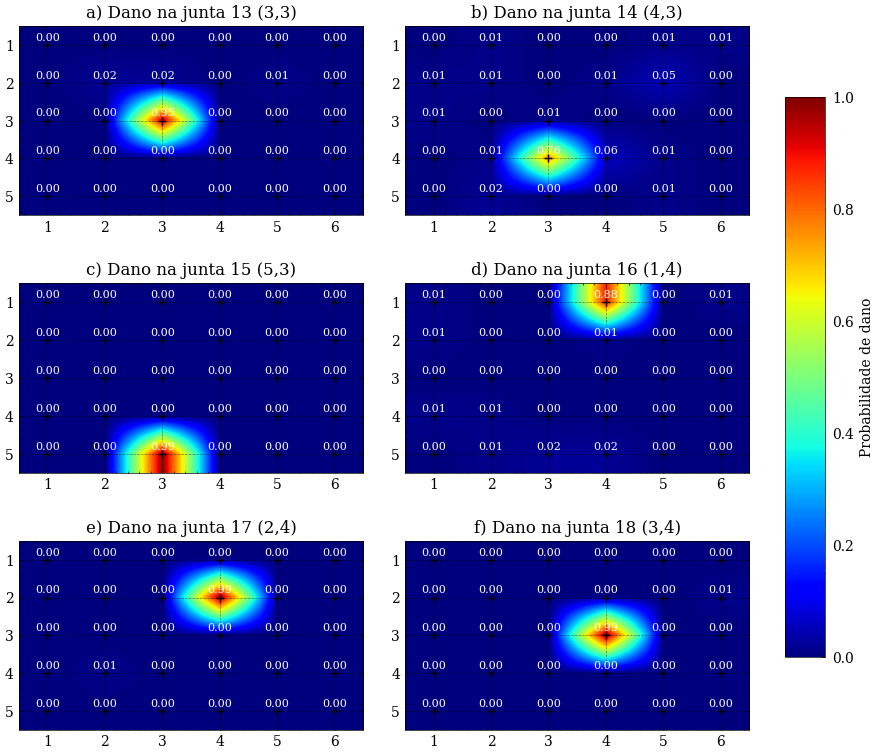

C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_9956\1229174110.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.0)


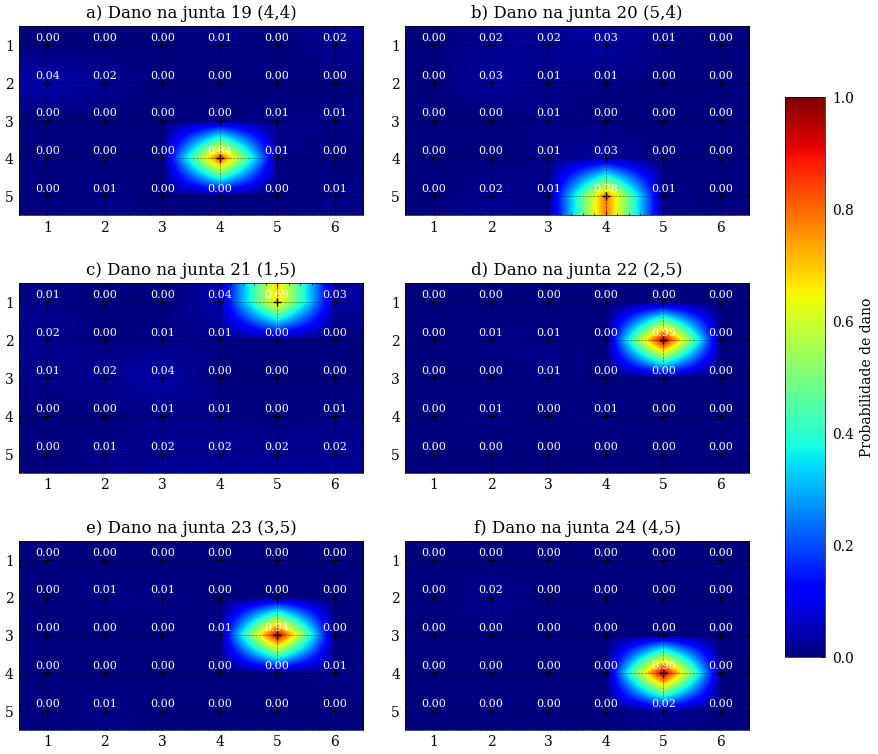

C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_9956\1229174110.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.0)


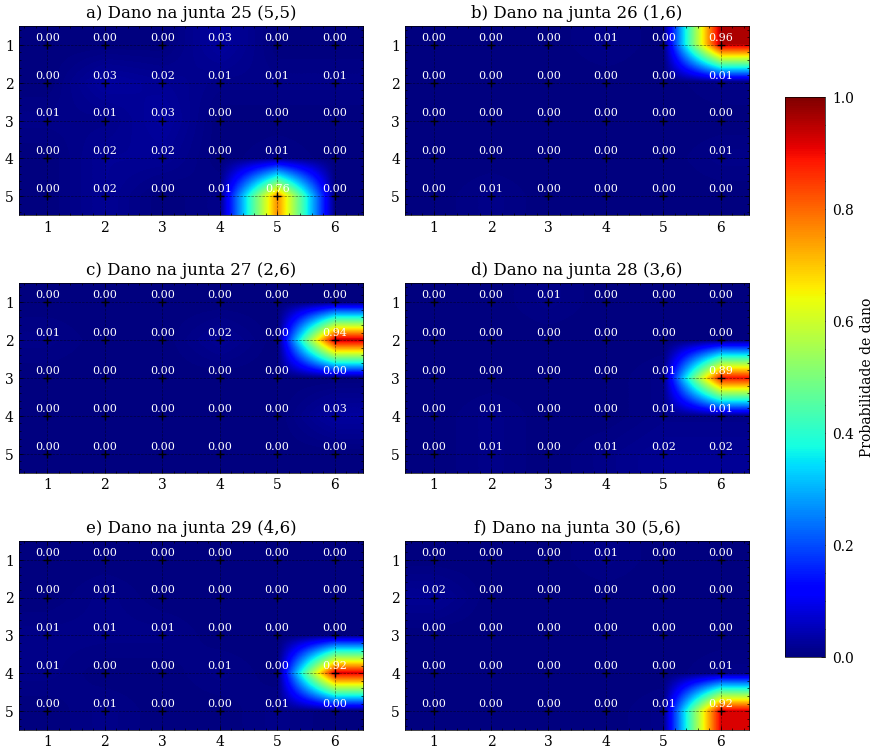

In [68]:
#Plot do apêndice

for k in range(5):
    fig = plt.figure(figsize=(8,8)) # Notice the equal aspect ratio
    ax = [fig.add_subplot(3,2,i+1) for i in range(6)]

    titulo = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']

    for i in range(len(ax)):
        j = (k*6+i)*128+128

        if k == 0 and i == 1:
            j = 312
        elif k == 0 and i == 3:
            j = 520
        elif k == 2 and i == 0:
            j = 1776
        elif k == 3 and i == 0:
            j = 2496
        elif k == 3 and i == 3:
            j = 2840

        title = f'{titulo[i]} Dano na junta {int(y_test[j])}'
        make_cbar = True if i == 0 else False
        plot_colormap(predictions=preds[j], axes=ax[i], titulo=title, colorbar=make_cbar, ytrue=y_test[j])

    plt.tight_layout(pad=2.0)

    # # Barra de cor estilizada
    # cbar_ax = fig.add_axes([1.01, 0.15, 0.05, 0.7])  # Posição da colorbar
    # cbar = fig.colorbar(heatmap, cax=cbar_ax)
    # cbar.set_label('Probabilidade de dano')  # Rótulo da colorbar
    # cbar.ax.tick_params(labelsize=10)  # Tamanho dos ticks
    # cbar.ax.yaxis.set_tick_params(pad=5)  # Espaçamento dos números na colorbar
    # cbar.outline.set_linewidth(0.5)  # Fino contorno da colorbar

    plt.show()
    saving_path = SAVE_PATH + f'/00 - Apendice A p{k+1}.pdf'
    fig.savefig(saving_path, bbox_inches='tight')


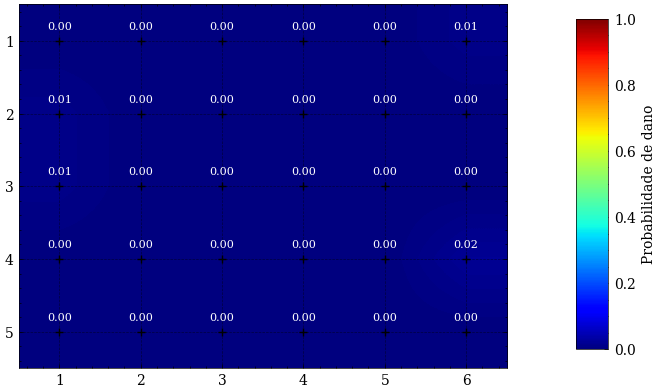

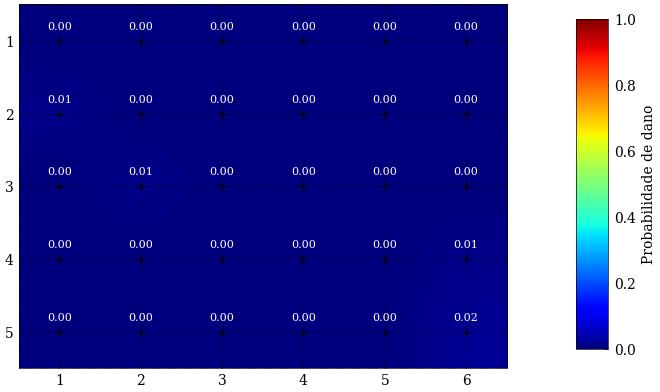

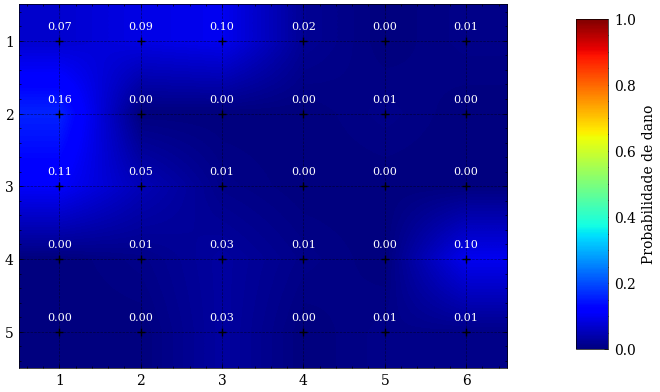

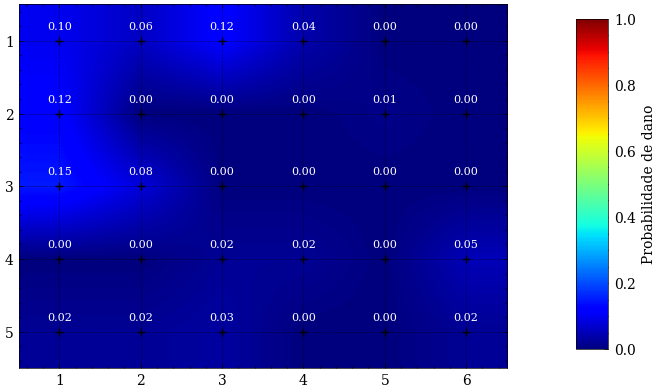

In [60]:
#Visualize the results
#Imagens utilizadas - [1776,2296]
#0,len(y_test),8

zeros = [43,  77,  1, 40]

# for i in range(0,len(y_test),32):
for i in zeros:
    fig, ax = plt.subplots(1)

    plot_colormap(predictions=preds[i], axes=ax, colorbar=True)

    # plt.tight_layout(pad=2.0)
    
    plt.show()
    saving_path = SAVE_PATH + f'/{y_test[i]} {i} Dano.pdf'
    # fig.savefig(saving_path, bbox_inches='tight')
    plt.close()

In [131]:
import itertools

#Define a matriz de confusão
cm = metrics.confusion_matrix(y_test, yhat)

#Normaliza o resultado
for i in range(cm.shape[0]):
    cm[i] = cm[i]/np.max(cm[i])*100

#Cria a figura e os eixos
fig, ax = plt.subplots(1)

#Número de classes para plotar
n_classes = cm.shape[0]

#Plota o gráfico
im_ = ax.imshow(cm)
cmap_min, cmap_max = im_.cmap(0), im_.cmap(1.0)

display_labels = np.arange(n_classes)

fig.colorbar(im_, ax=ax)

ax.set(
    xticks=np.arange(n_classes),
    yticks=np.arange(n_classes),
    xticklabels=display_labels,
    yticklabels=display_labels,
    ylabel="Valor verdadeiro",
    xlabel="Valor predito",
)

ax.text(5, 10, f'{cm[10,5]}%', ha="center", va="center", color="w")
ax.scatter(5,10, marker='s', s=300, color='r', facecolors='none', alpha=0.8)

ax.set_ylim((n_classes - 0.5, -0.5))
plt.setp(ax.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

saving_path = SAVE_PATH + '/00 - Matriz de confusão.pdf'
fig.savefig(saving_path, format='pdf', dpi=300, bbox_inches='tight', transparent=False)


C:\Users\Guilherme Zerwes\AppData\Local\Temp\ipykernel_9956\757446584.py:40: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
